# Mini-Projet Data Mining
**Dataset :** Student_Performance.csv · 25 000 observations · 16 variables  
**Objectif :** Analyse exploratoire, descriptive et prédictive

---

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA

# Constantes globales
PALETTE      = ["#2196F3","#4CAF50","#FF9800","#E91E63","#9C27B0","#00BCD4"]
BLUE         = "#2196F3"
GRADE_ORDER  = ["a","b","c","d","e","f"]
GRADE_LABELS = ["A-Excellent","B-Bien","C-Assez bien","D-Passable","E-Faible","F-Echec"]
GRADE_COLORS = ["#4CAF50","#8BC34A","#FFC107","#FF9800","#F44336","#9C27B0"]
NUM_COLS     = ["study_hours","attendance_percentage","math_score","science_score","english_score","overall_score"]
SCORE_COLS   = ["math_score","science_score","english_score"]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi":110, "axes.titlesize":13,
                     "axes.labelsize":11, "figure.facecolor":"white"})

---
## Phase 1 — Importation & Nettoyage

In [2]:
df = pd.read_csv("Student_PerformanceDM.csv")

# Suppression ID + doublons
df.drop(columns=["student_id"], inplace=True)
nb_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dimensions   : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Manquantes   : {df.isnull().sum().sum()}")
print(f"Doublons sup.: {nb_dup:,}")
df.head(3)

Dimensions   : 15,000 lignes x 15 colonnes
Manquantes   : 0
Doublons sup.: 10,000


,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b


In [3]:
# Statistiques de base
df[NUM_COLS].describe().round(2)

,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,4.26,74.99,63.77,63.75,63.71,64.02
std,2.17,14.40,20.92,21.03,20.86,18.98
min,0.50,50.00,0.00,0.00,0.00,14.50
25%,2.40,62.60,48.20,48.10,48.30,49.00
50%,4.30,75.00,64.10,64.00,64.20,64.30
75%,6.10,87.40,80.10,80.10,80.00,79.10
max,8.00,100.00,100.00,100.00,100.00,100.00


In [4]:
# Outliers IQR (informatif — conservés car valeurs réalistes)
for col in NUM_COLS:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    n_out = ((df[col] < Q1-1.5*(Q3-Q1)) | (df[col] > Q3+1.5*(Q3-Q1))).sum()
    print(f"  {col:<28}: {n_out:>3} outliers")

  study_hours                 :   0 outliers
  attendance_percentage       :   0 outliers
  math_score                  :   5 outliers
  science_score               :   4 outliers
  english_score               :   2 outliers
  overall_score               :   0 outliers


In [5]:
# Encodage des catégorielles pour ML
cat_cols = ["gender","school_type","parent_education","internet_access",
            "travel_time","extra_activities","study_method","final_grade"]

df_enc = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[f"{col}_enc"] = le.fit_transform(df_enc[col])

---
## Phase 2 — Statistiques Descriptives Univariées

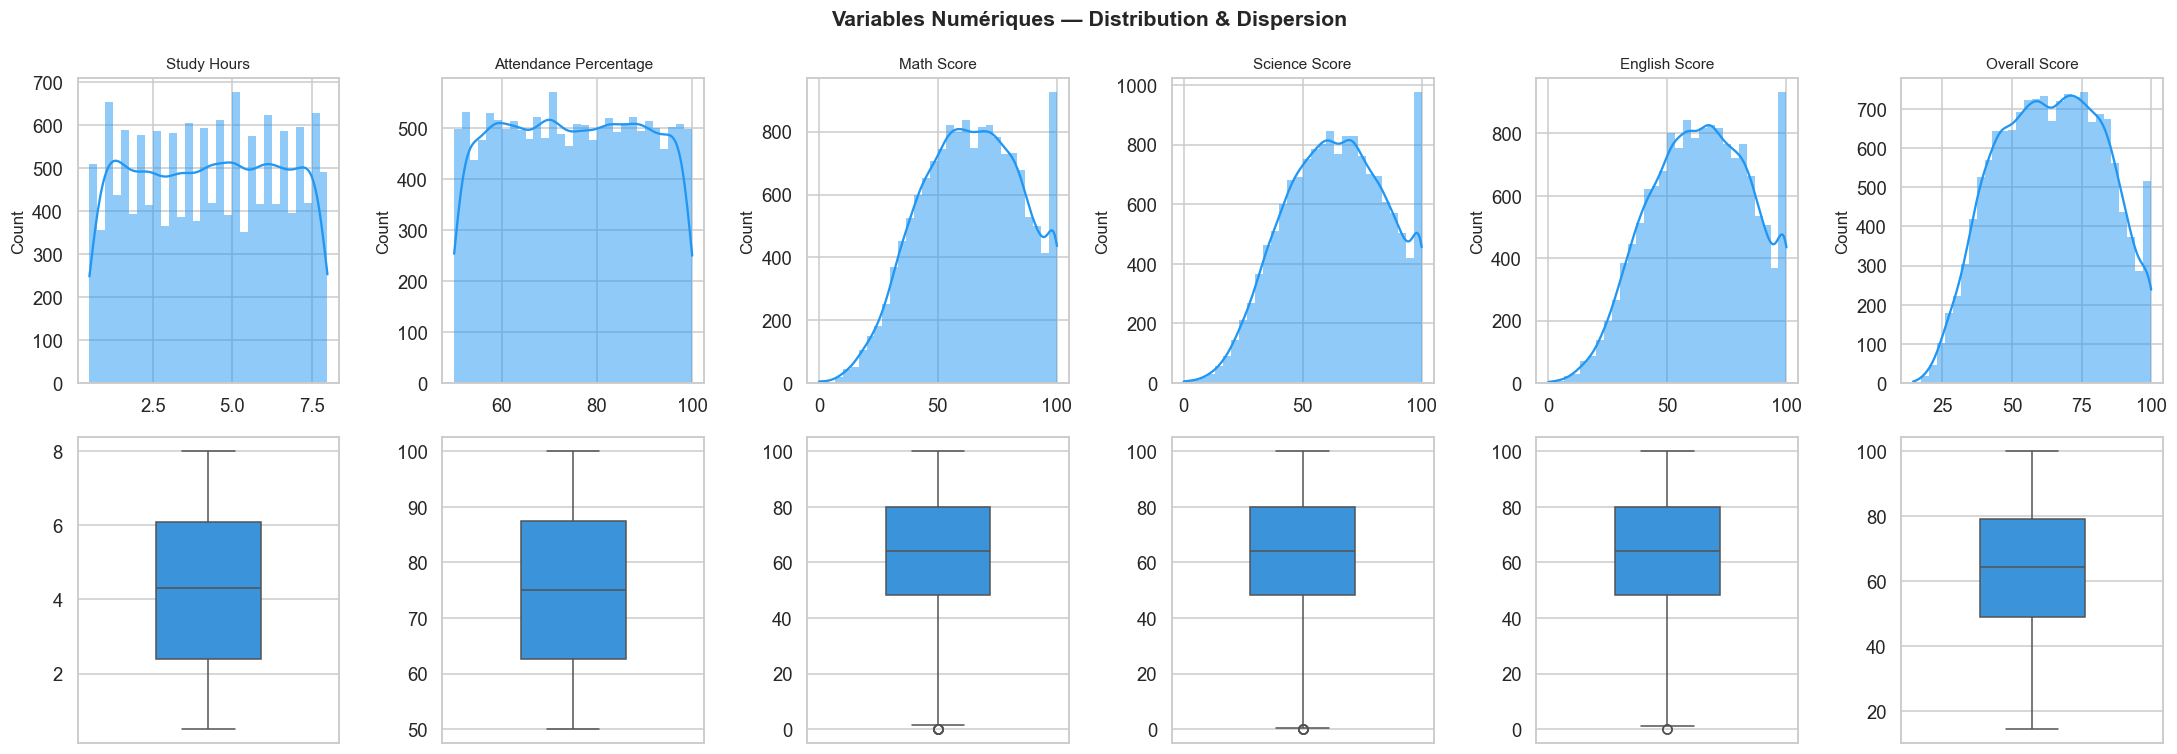

In [6]:
# Variables numériques : histogrammes + boxplots
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle("Variables Numériques — Distribution & Dispersion", fontsize=14, fontweight="bold")

for i, col in enumerate(NUM_COLS):
    sns.histplot(df[col], kde=True, color=BLUE, ax=axes[0,i], bins=30, linewidth=0)
    axes[0,i].set_title(col.replace("_"," ").title(), fontsize=10)
    axes[0,i].set_xlabel("")

    sns.boxplot(y=df[col], color=BLUE, ax=axes[1,i], width=0.4)
    axes[1,i].set_title("")
    axes[1,i].set_ylabel("")

plt.tight_layout()
plt.show()

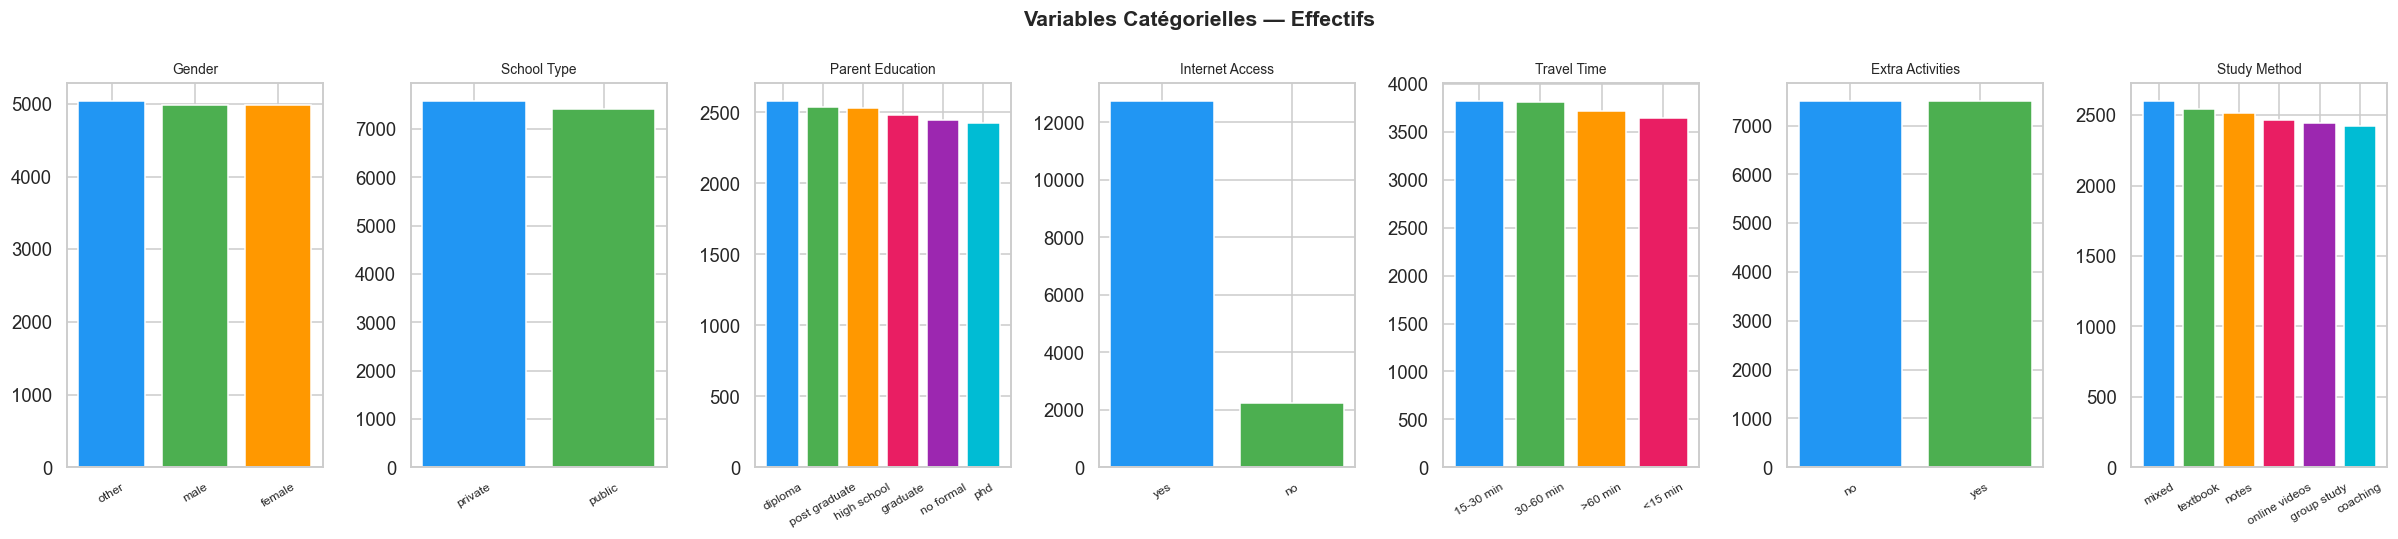

In [7]:
# Variables catégorielles
cat_plot = ["gender","school_type","parent_education","internet_access",
            "travel_time","extra_activities","study_method"]

fig, axes = plt.subplots(1, 7, figsize=(22, 5))
fig.suptitle("Variables Catégorielles — Effectifs", fontsize=14, fontweight="bold")

for ax, col in zip(axes, cat_plot):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor="white")
    ax.set_title(col.replace("_"," ").title(), fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

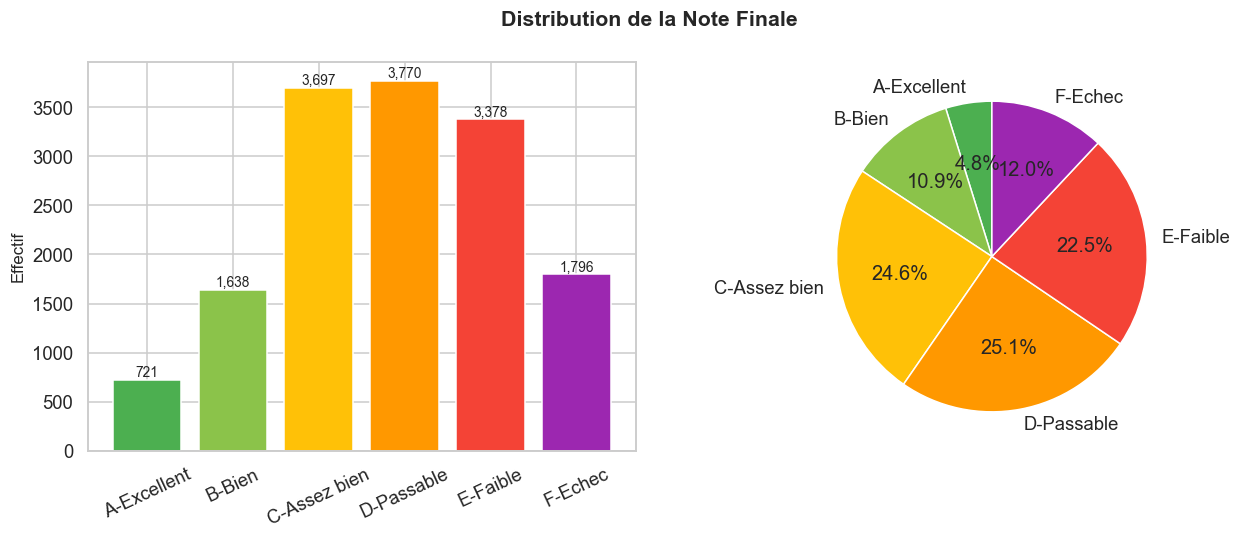

In [8]:
# Variable cible : final_grade
vc = df["final_grade"].value_counts().reindex(GRADE_ORDER)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribution de la Note Finale", fontsize=14, fontweight="bold")

ax1.bar(GRADE_LABELS, vc.values, color=GRADE_COLORS, edgecolor="white")
ax1.set_ylabel("Effectif")
ax1.tick_params(axis="x", rotation=25)
for i, v in enumerate(vc.values):
    ax1.text(i, v+30, f"{v:,}", ha="center", fontsize=9)

ax2.pie(vc.values, labels=GRADE_LABELS, colors=GRADE_COLORS,
        autopct="%1.1f%%", startangle=90, wedgeprops=dict(edgecolor="white"))
plt.tight_layout()
plt.show()

---
## Phase 3 — Analyse de Fiabilité (Alpha de Cronbach)
> Vérifie si math, science et anglais mesurent un même concept latent (performance académique).

Alpha de Cronbach = 0.9170  →  Acceptable fiabilité


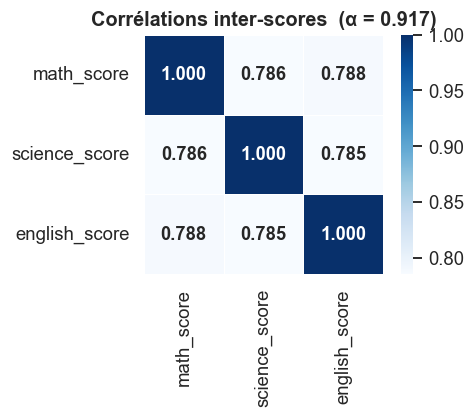

In [9]:
def cronbach_alpha(data):
    k = data.shape[1]
    return (k/(k-1)) * (1 - data.var(ddof=1).sum() / data.sum(axis=1).var(ddof=1))

alpha = cronbach_alpha(df[SCORE_COLS])
interp = {alpha >= 0.9: "Excellente", alpha >= 0.8: "Bonne",
          alpha >= 0.7: "Acceptable"}.get(True, "Faible")

print(f"Alpha de Cronbach = {alpha:.4f}  →  {interp} fiabilité")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[SCORE_COLS].corr(), annot=True, fmt=".3f", cmap="Blues",
            ax=ax, square=True, linewidths=0.5, annot_kws={"size":12,"weight":"bold"})
ax.set_title(f"Corrélations inter-scores  (α = {alpha:.3f})", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Phase 4 — Statistiques Bivariées

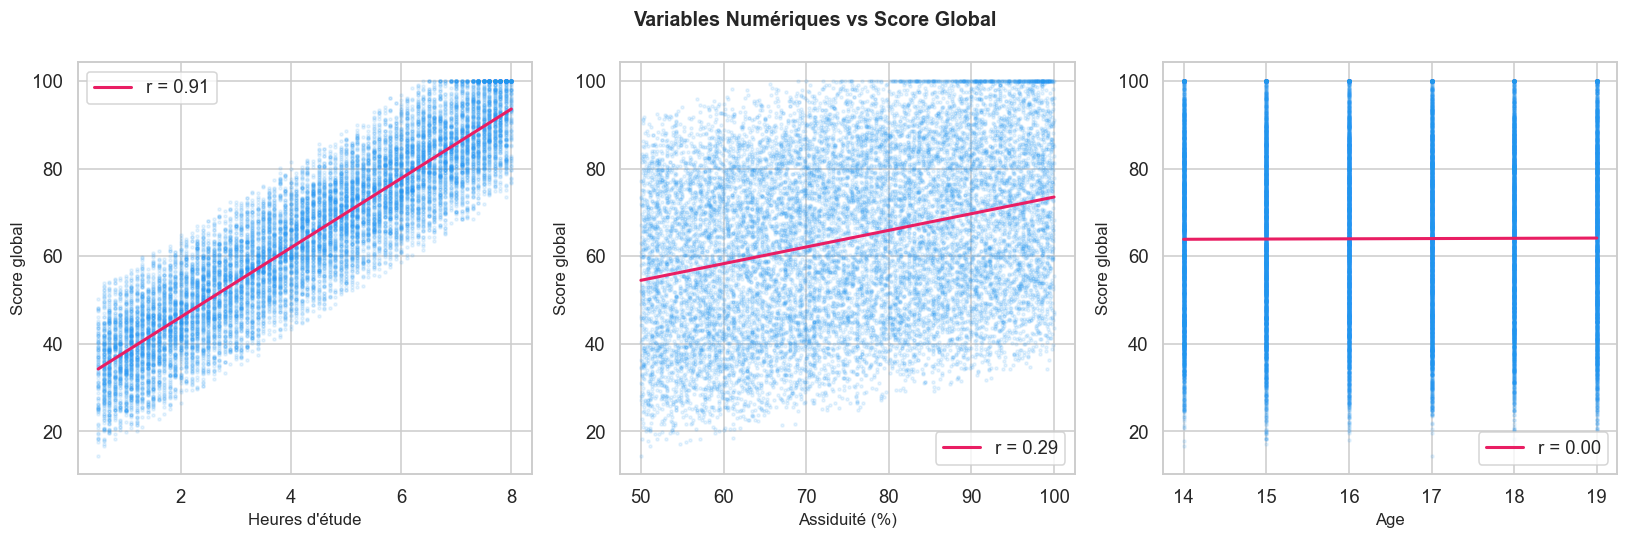

In [10]:
# Numérique × Numérique : scatter + droite de tendance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Variables Numériques vs Score Global", fontsize=13, fontweight="bold")

for ax, (x, lbl) in zip(axes, [("study_hours","Heures d'étude"),
                                 ("attendance_percentage","Assiduité (%)"),
                                 ("age","Age")]):
    ax.scatter(df[x], df["overall_score"], alpha=0.1, color=BLUE, s=4)
    m, b = np.polyfit(df[x], df["overall_score"], 1)
    xl = np.linspace(df[x].min(), df[x].max(), 100)
    r  = df[x].corr(df["overall_score"])
    ax.plot(xl, m*xl+b, color="#E91E63", lw=2, label=f"r = {r:.2f}")
    ax.set_xlabel(lbl); ax.set_ylabel("Score global"); ax.legend()
plt.tight_layout()
plt.show()

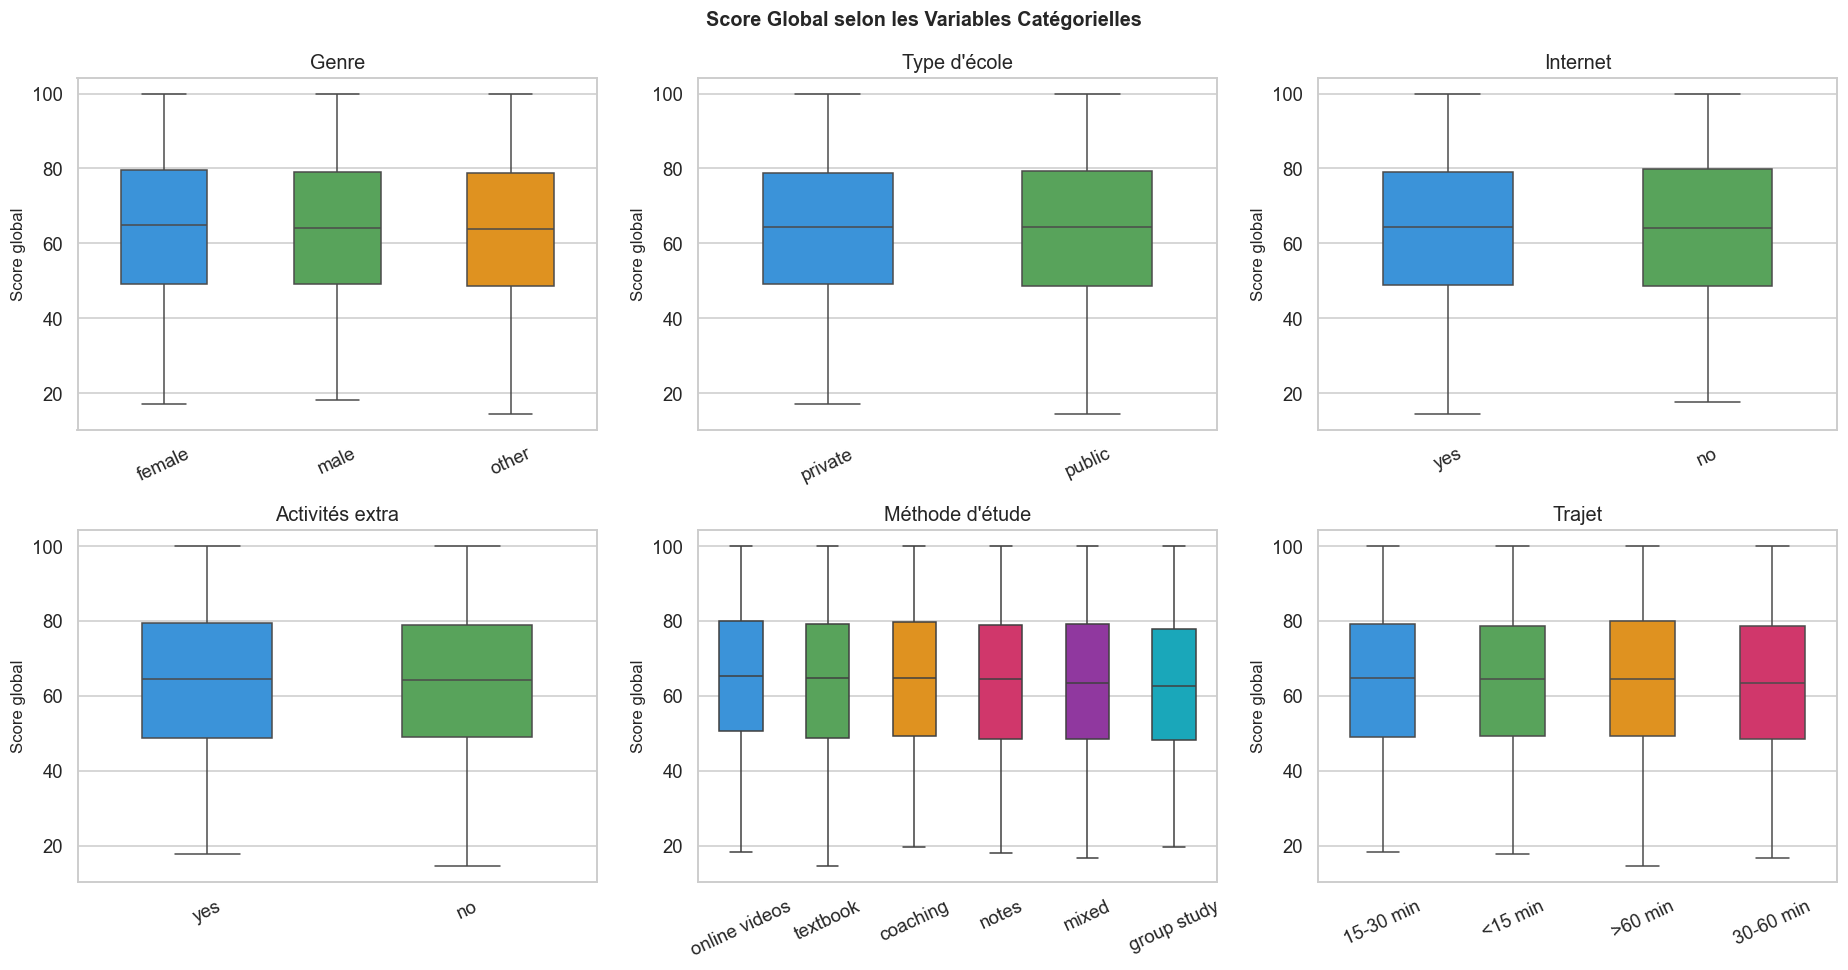

In [11]:
# Numérique × Catégorielle : boxplots comparatifs
cat_pairs = [("gender","Genre"), ("school_type","Type d'école"),
             ("internet_access","Internet"), ("extra_activities","Activités extra"),
             ("study_method","Méthode d'étude"), ("travel_time","Trajet")]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Score Global selon les Variables Catégorielles", fontsize=13, fontweight="bold")

for ax, (cat, title) in zip(axes.flat, cat_pairs):
    order = df.groupby(cat)["overall_score"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=cat, y="overall_score", order=order,
                palette=PALETTE[:df[cat].nunique()], ax=ax, width=0.5)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Score global")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

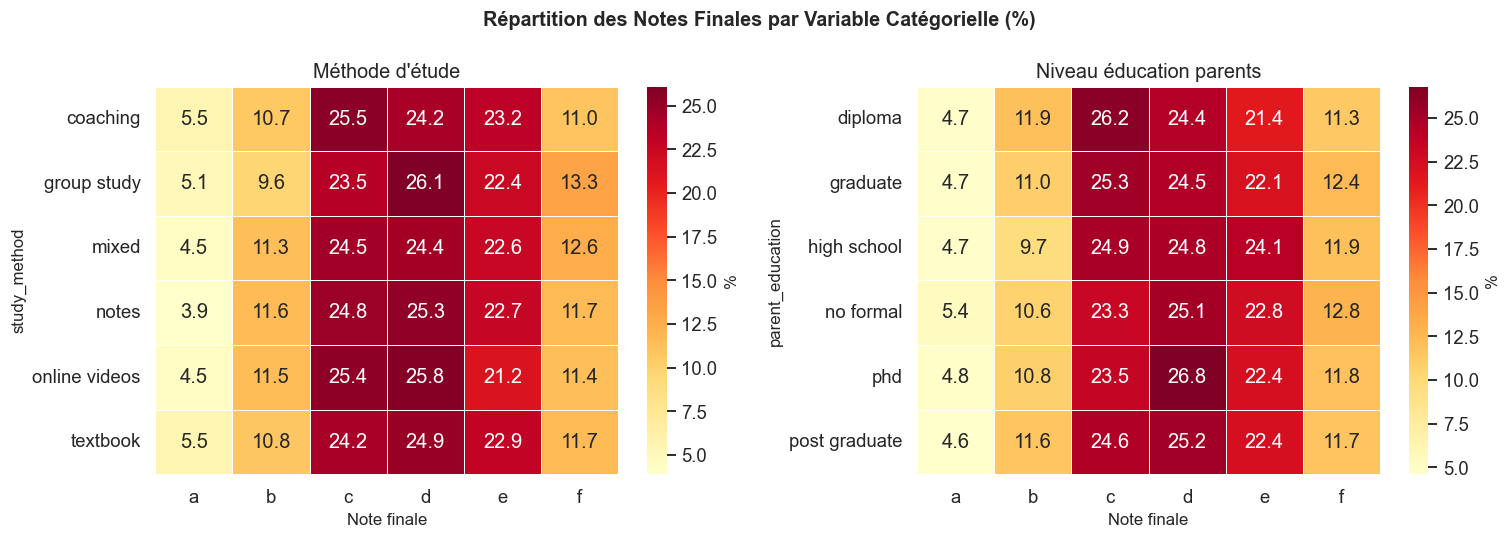

In [12]:
# Catégorielle × Catégorielle : tableaux croisés normalisés
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Répartition des Notes Finales par Variable Catégorielle (%)",
             fontsize=13, fontweight="bold")

for ax, col, title in zip(axes,
        ["study_method","parent_education"],
        ["Méthode d'étude","Niveau éducation parents"]):
    cross = pd.crosstab(df[col], df["final_grade"], normalize="index")[GRADE_ORDER] * 100
    sns.heatmap(cross.round(1), annot=True, fmt=".1f", cmap="YlOrRd",
                ax=ax, linewidths=0.4, cbar_kws={"label":"%"})
    ax.set_title(title); ax.set_xlabel("Note finale")

plt.tight_layout()
plt.show()

---
## Phase 5 — Statistiques Multivariées

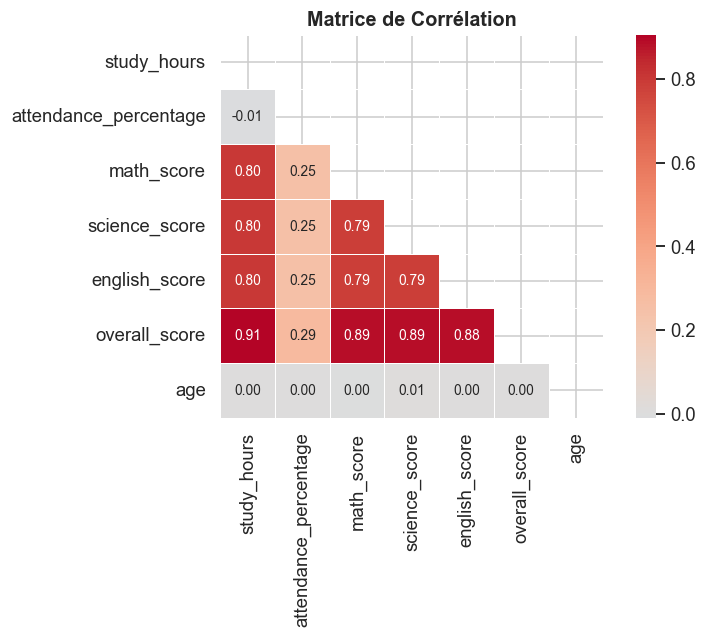

In [13]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[NUM_COLS + ["age"]].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax, linewidths=0.4, square=True, annot_kws={"size":9})
ax.set_title("Matrice de Corrélation", fontweight="bold")
plt.tight_layout()
plt.show()

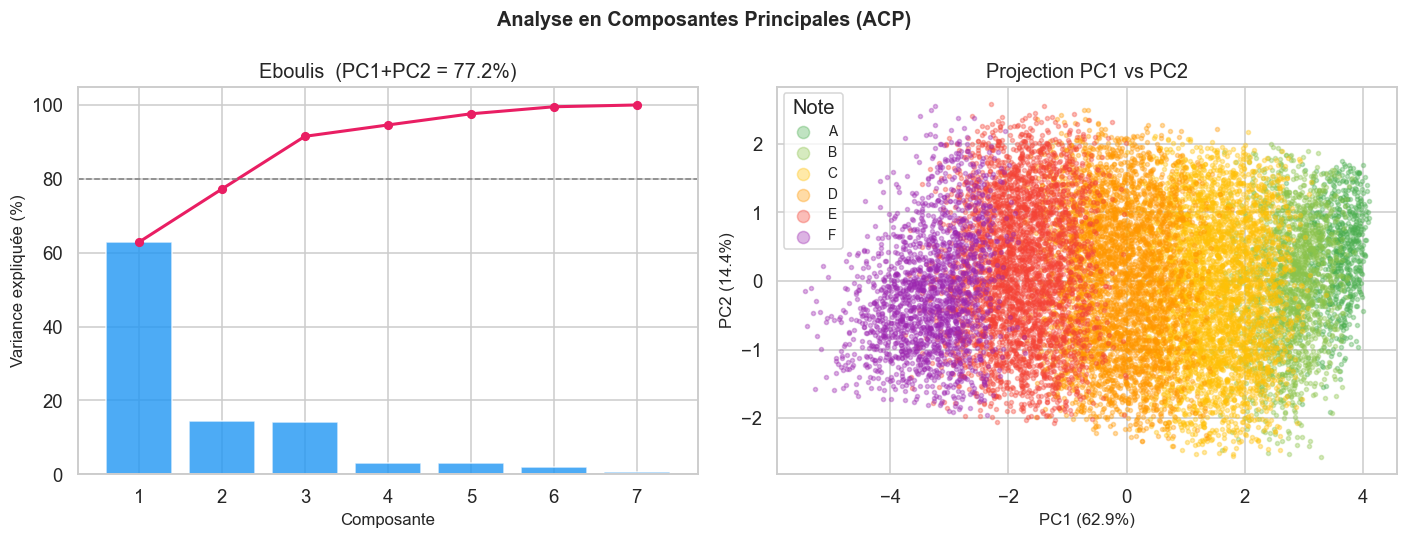

In [14]:
# ACP — éboulis + projection 2D
X_sc = StandardScaler().fit_transform(df[NUM_COLS + ["age"]])
pca_full = PCA().fit(X_sc)
pca2     = PCA(n_components=2)
coords   = pca2.fit_transform(X_sc)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Analyse en Composantes Principales (ACP)", fontsize=13, fontweight="bold")

# Eboulis
ax1.bar(range(1, len(cum_var)+1), pca_full.explained_variance_ratio_*100,
        color=BLUE, alpha=0.8)
ax1.plot(range(1, len(cum_var)+1), cum_var*100, "o-", color="#E91E63", lw=2, ms=5)
ax1.axhline(80, color="gray", ls="--", lw=1)
ax1.set(xlabel="Composante", ylabel="Variance expliquée (%)",
        title=f"Eboulis  (PC1+PC2 = {cum_var[1]*100:.1f}%)",
        xticks=range(1, len(cum_var)+1))

# Projection 2D
for g, c in zip(GRADE_ORDER, GRADE_COLORS):
    m = df["final_grade"] == g
    ax2.scatter(coords[m,0], coords[m,1], c=c, alpha=0.35, s=7, label=g.upper())
ax2.set(xlabel=f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)",
        ylabel=f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)",
        title="Projection PC1 vs PC2")
ax2.legend(markerscale=3, fontsize=9, title="Note")
plt.tight_layout()
plt.show()

---
## Phase 6 — Règles d'Association (Apriori)
> Discrétisation des variables numériques → items → itemsets fréquents → règles  
> Seuils : support ≥ 10% · confiance ≥ 50% · lift ≥ 1.2

In [15]:
# Discrétisation + construction des transactions
df_a = df.copy()
df_a["perf"]     = pd.cut(df["overall_score"],         bins=[0,49,69,100], labels=["perf_low","perf_mid","perf_high"])
df_a["etude"]    = pd.cut(df["study_hours"],           bins=[0,3,6,24],    labels=["study_low","study_mid","study_high"])
df_a["presence"] = pd.cut(df["attendance_percentage"], bins=[0,59,79,100], labels=["att_low","att_mid","att_high"])

assoc_cols = ["perf","etude","presence","internet_access","school_type","extra_activities","study_method"]
flag_cols  = {"internet_access","school_type","extra_activities"}

transactions = [
    [f"{col}_{row[col]}" if col in flag_cols else str(row[col])
     for col in assoc_cols]
    for _, row in df_a[assoc_cols].iterrows()
]
print(f"Transactions : {len(transactions):,}  |  Exemple : {transactions[0]}")

Transactions : 15,000  |  Exemple : ['perf_mid', 'study_mid', 'att_high', 'internet_access_yes', 'school_type_public', 'extra_activities_yes', 'notes']


In [16]:
# Algorithme Apriori
def apriori(transactions, min_sup=0.10):
    n = len(transactions)
    cnt = defaultdict(int)
    for t in transactions:
        for item in set(t): cnt[item] += 1
    freq = {frozenset([k]): v/n for k,v in cnt.items() if v/n >= min_sup}
    all_f, cur, k = dict(freq), list(freq), 2
    while cur and k <= 4:
        cands = {}
        items = sorted({i for fs in cur for i in fs})
        for combo in combinations(items, k):
            fs = frozenset(combo)
            if all(frozenset(s) in all_f for s in combinations(combo, k-1)):
                sup = sum(1 for t in transactions if fs <= set(t)) / n
                if sup >= min_sup: cands[fs] = sup
        all_f.update(cands); cur = list(cands); k += 1
    return all_f

def gen_rules(freq, min_conf=0.5, min_lift=1.2):
    rows = []
    for fs, s_fs in freq.items():
        if len(fs) < 2: continue
        for i in range(1, len(fs)):
            for ant in map(frozenset, combinations(sorted(fs), i)):
                con = fs - ant
                s_a, s_c = freq.get(ant), freq.get(con)
                if s_a and s_c:
                    conf = s_fs/s_a; lift = conf/s_c
                    if conf >= min_conf and lift >= min_lift:
                        rows.append({"antecedents": ant, "consequents": con,
                                     "support": round(s_fs,4),
                                     "confidence": round(conf,4), "lift": round(lift,4)})
    return pd.DataFrame(rows).sort_values("lift", ascending=False) if rows else pd.DataFrame()

freq_items = apriori(transactions)
rules      = gen_rules(freq_items)
print(f"Itemsets frequents : {len(freq_items)}  |  Regles : {len(rules)}")

Itemsets frequents : 176  |  Regles : 73


In [17]:
# Top 10 règles
top10 = rules.head(10).copy()
top10["antecedents"] = top10["antecedents"].apply(lambda x: ", ".join(sorted(x)))
top10["consequents"] = top10["consequents"].apply(lambda x: ", ".join(sorted(x)))
top10.index = range(1,11)
top10

,antecedents,consequents,support,confidence,lift
1,"att_mid, study_low",perf_low,0.1073,0.7931,3.1539
2,"att_mid, perf_low",study_low,0.1073,0.9312,2.7604
3,"school_type_public, study_low",perf_low,0.1159,0.6909,2.7475
4,"extra_activities_yes, study_low",perf_low,0.1155,0.6906,2.7462
5,"extra_activities_no, perf_low",study_low,0.1151,0.9200,2.7274
6,perf_low,"internet_access_yes, study_low",0.1954,0.7770,2.7252
7,"internet_access_yes, study_low",perf_low,0.1954,0.6853,2.7252
8,study_low,"internet_access_yes, perf_low",0.1954,0.5792,2.7212
9,"internet_access_yes, perf_low",study_low,0.1954,0.9179,2.7212
10,"perf_low, school_type_public",study_low,0.1159,0.9172,2.7190


---
## Phase 7 — Classification Supervisée : Decision Tree vs Random Forest

In [18]:
# Préparation features / target
features = ["age","study_hours","attendance_percentage",
            "math_score","science_score","english_score",
            "gender_enc","school_type_enc","parent_education_enc",
            "internet_access_enc","travel_time_enc","extra_activities_enc","study_method_enc"]

df_enc["final_grade_enc"] = df_enc["final_grade"].map({"f":0,"e":1,"d":2,"c":3,"b":4,"a":5})

X_tr, X_te, y_tr, y_te = train_test_split(
    df_enc[features], df_enc["final_grade_enc"],
    test_size=0.25, random_state=42, stratify=df_enc["final_grade_enc"])

print(f"Train : {len(X_tr):,}  |  Test : {len(X_te):,}  |  Features : {len(features)}")

Train : 11,250  |  Test : 3,750  |  Features : 13


In [19]:
# Entraînement des deux modèles
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             min_samples_leaf=20, n_jobs=-1, random_state=42)

dt.fit(X_tr, y_tr); rf.fit(X_tr, y_tr)
y_dt = dt.predict(X_te); y_rf = rf.predict(X_te)

acc_dt = accuracy_score(y_te, y_dt)
acc_rf = accuracy_score(y_te, y_rf)

print(f"Decision Tree  → Accuracy : {acc_dt*100:.2f}%")
print(f"Random Forest  → Accuracy : {acc_rf*100:.2f}%")

Decision Tree  → Accuracy : 67.97%
Random Forest  → Accuracy : 74.69%


In [20]:
# Rapports de classification
CLS = ["F","E","D","C","B","A"]
print("── Decision Tree ──")
print(classification_report(y_te, y_dt, target_names=CLS))
print("── Random Forest ──")
print(classification_report(y_te, y_rf, target_names=CLS))

── Decision Tree ──
              precision    recall  f1-score   support

           F       0.78      0.68      0.72       449
           E       0.67      0.71      0.69       845
           D       0.69      0.69      0.69       942
           C       0.69      0.74      0.71       924
           B       0.54      0.56      0.55       410
           A       0.80      0.43      0.56       180

    accuracy                           0.68      3750
   macro avg       0.69      0.64      0.65      3750
weighted avg       0.68      0.68      0.68      3750

── Random Forest ──
              precision    recall  f1-score   support

           F       0.82      0.71      0.76       449
           E       0.73      0.75      0.74       845
           D       0.75      0.77      0.76       942
           C       0.75      0.83      0.79       924
           B       0.66      0.60      0.63       410
           A       0.85      0.57      0.68       180

    accuracy                         

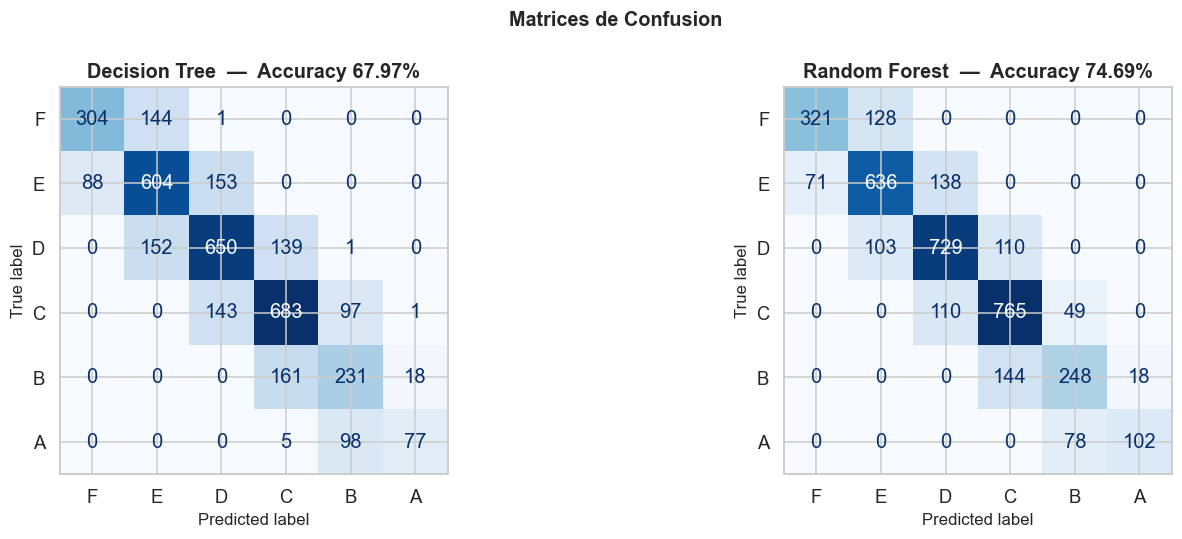

In [21]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Matrices de Confusion", fontsize=13, fontweight="bold")

for ax, yp, title, acc in zip(axes, [y_dt, y_rf],
                               ["Decision Tree","Random Forest"], [acc_dt, acc_rf]):
    ConfusionMatrixDisplay(confusion_matrix(y_te, yp), display_labels=CLS).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{title}  —  Accuracy {acc*100:.2f}%", fontweight="bold")
plt.tight_layout()
plt.show()

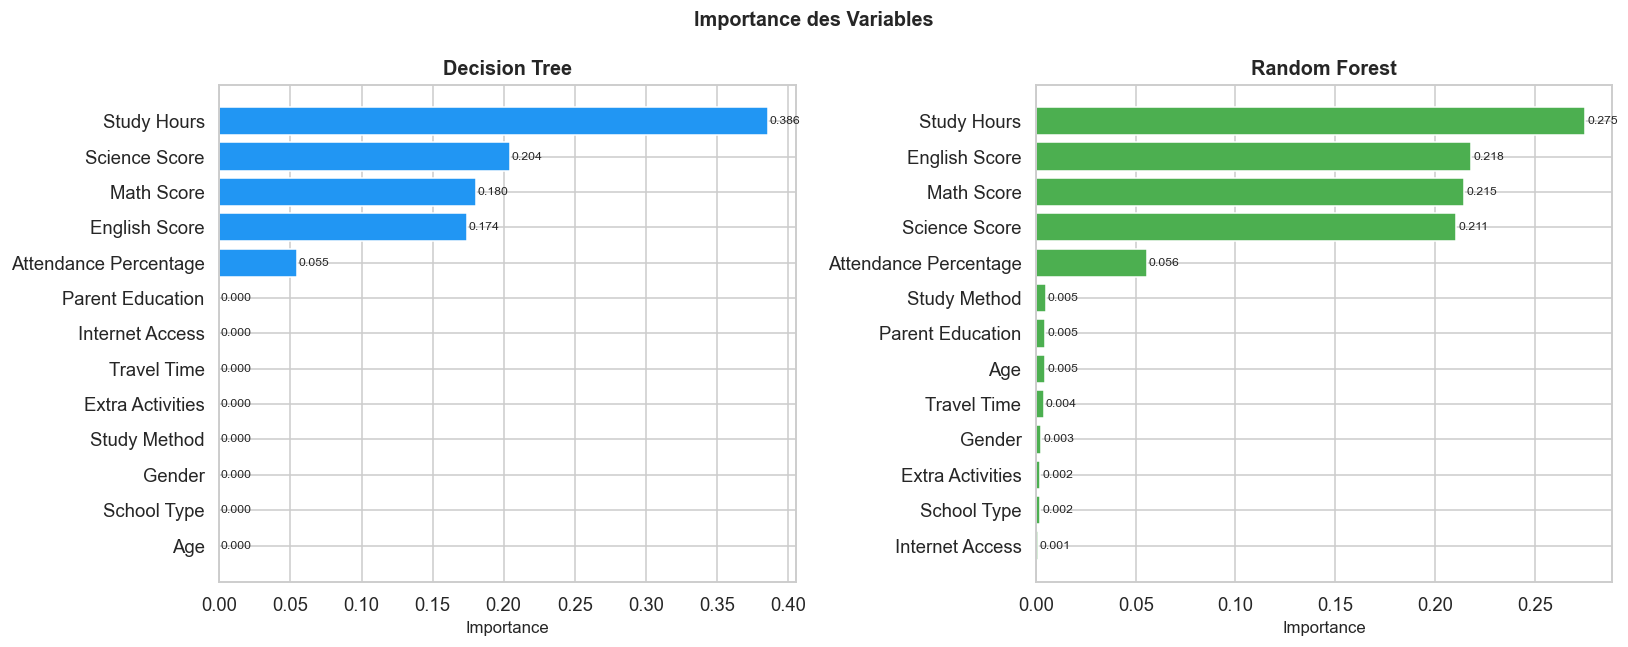

In [22]:
# Importance des variables
fi_dt = pd.Series(dt.feature_importances_, index=features).sort_values()
fi_rf = pd.Series(rf.feature_importances_, index=features).sort_values()
clean = lambda s: s.replace("_enc","").replace("_"," ").title()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Importance des Variables", fontsize=13, fontweight="bold")

for ax, fi, title, color in zip(axes, [fi_dt, fi_rf],
                                  ["Decision Tree","Random Forest"], [BLUE,"#4CAF50"]):
    ax.barh([clean(f) for f in fi.index], fi.values, color=color, edgecolor="white")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Importance")
    for i,v in enumerate(fi.values):
        ax.text(v+0.001, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

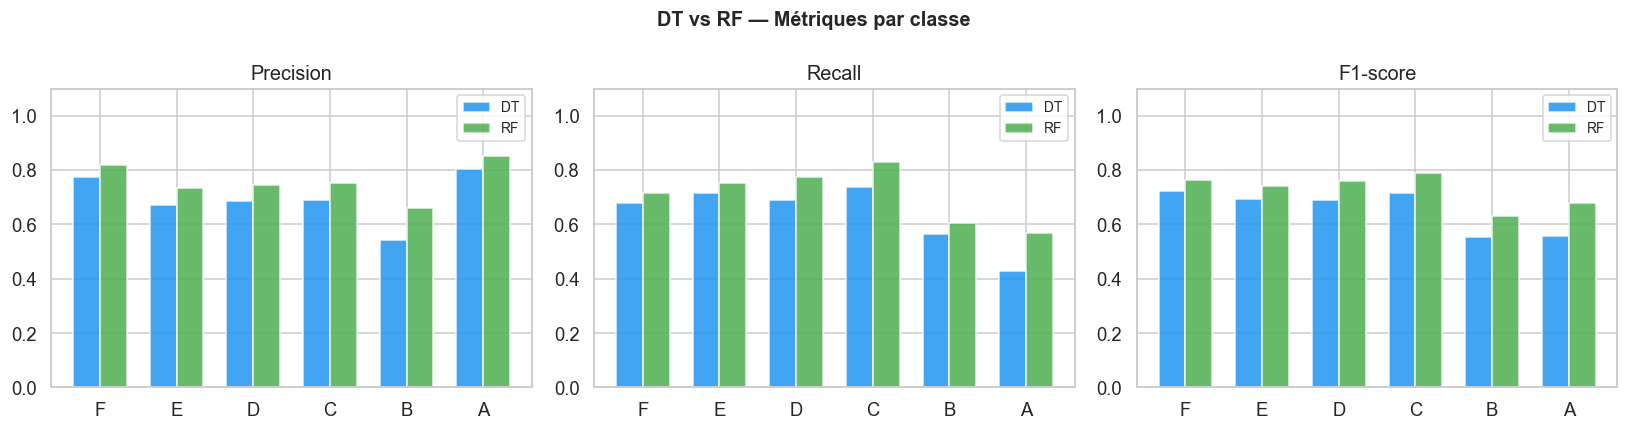

In [23]:
# Comparaison des métriques par classe
r_dt = classification_report(y_te, y_dt, target_names=CLS, output_dict=True)
r_rf = classification_report(y_te, y_rf, target_names=CLS, output_dict=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("DT vs RF — Métriques par classe", fontsize=13, fontweight="bold")
x, w = np.arange(len(CLS)), 0.35

for ax, metric in zip(axes, ["precision","recall","f1-score"]):
    ax.bar(x-w/2, [r_dt[c][metric] for c in CLS], w, label="DT",  color=BLUE,     alpha=0.85)
    ax.bar(x+w/2, [r_rf[c][metric] for c in CLS], w, label="RF",  color="#4CAF50", alpha=0.85)
    ax.set(xticks=x, xticklabels=CLS, ylim=(0,1.1), title=metric.capitalize())
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

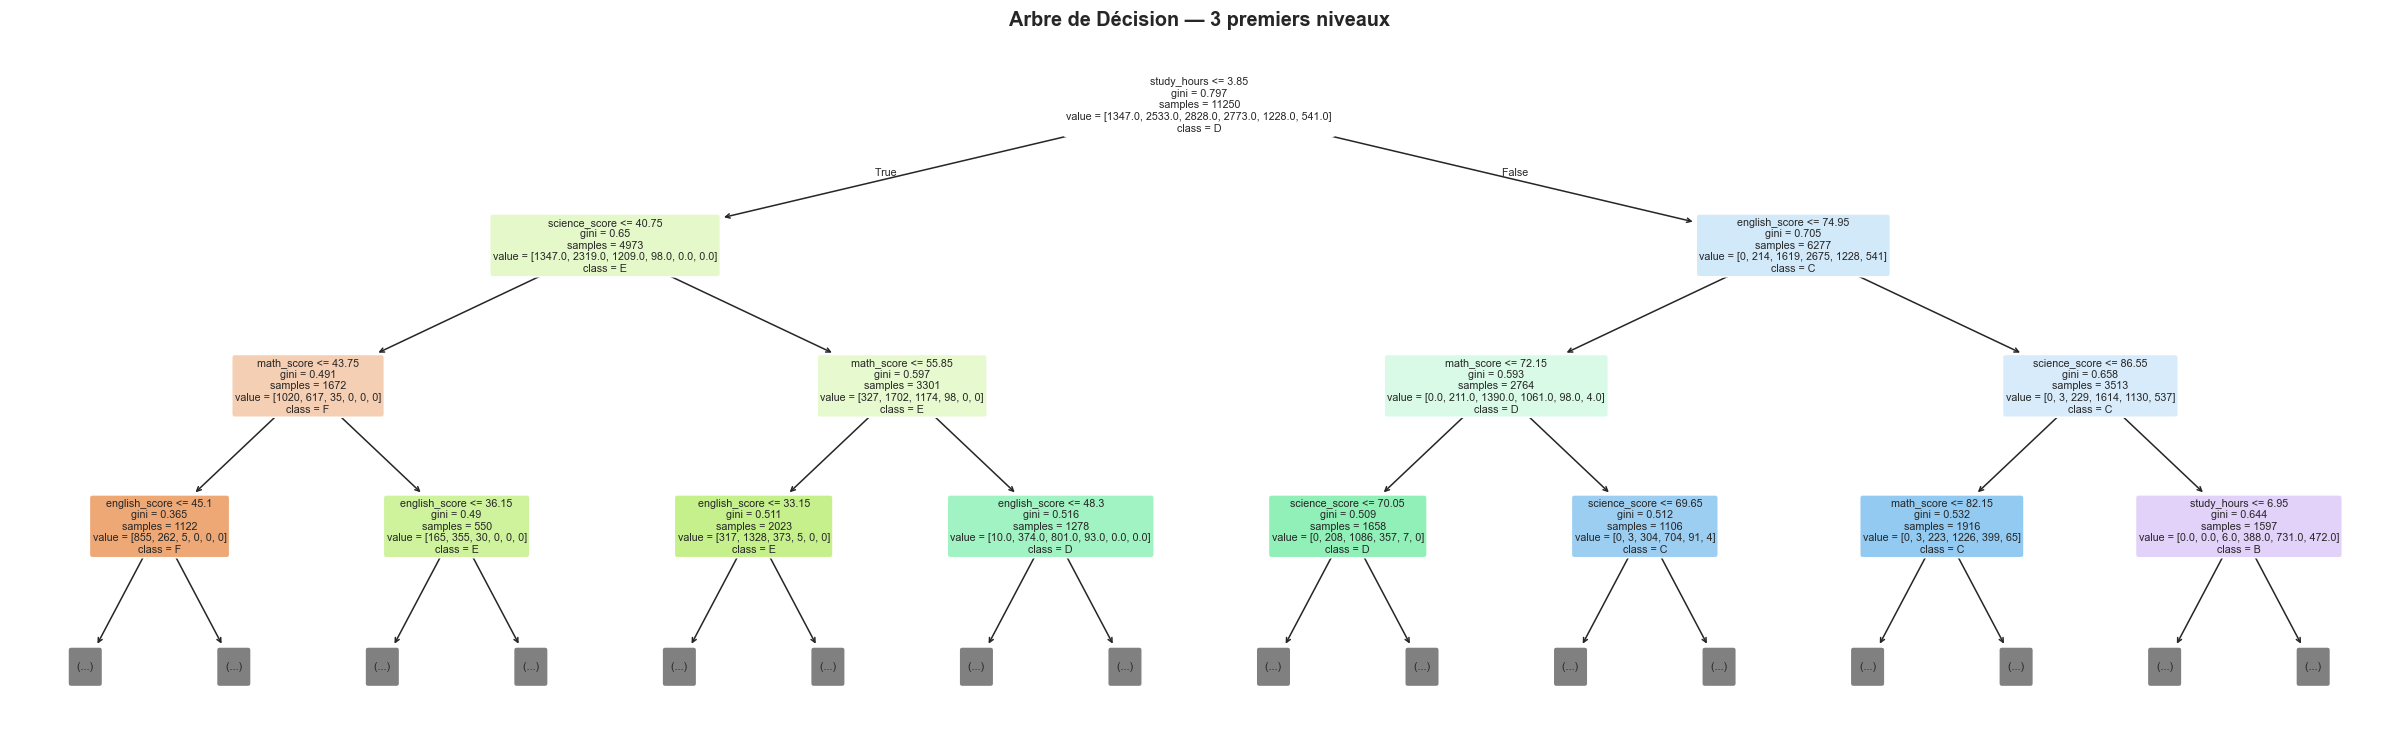

In [24]:
# Visualisation de l'arbre (3 niveaux)
fig, ax = plt.subplots(figsize=(22, 7))
plot_tree(dt, max_depth=3, feature_names=features, class_names=CLS,
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title("Arbre de Décision — 3 premiers niveaux", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Phase 8 — Idées Innovantes

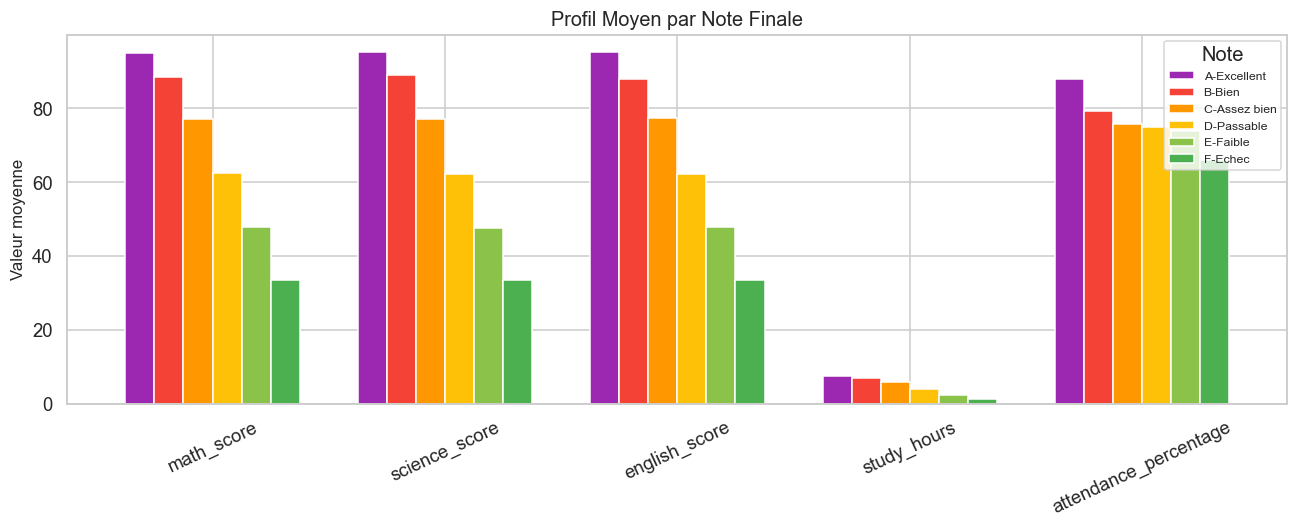

In [25]:
# Profil moyen par note + Radar Chart
profile = df.groupby("final_grade")[SCORE_COLS + ["study_hours","attendance_percentage"]].mean()
profile = profile.reindex(GRADE_ORDER)

# Profil moyen (barplot)
fig, ax = plt.subplots(figsize=(12, 5))
profile.T.plot(kind="bar", ax=ax, color=GRADE_COLORS[::-1], width=0.75, edgecolor="white")
ax.set(title="Profil Moyen par Note Finale", ylabel="Valeur moyenne")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Note", labels=GRADE_LABELS, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

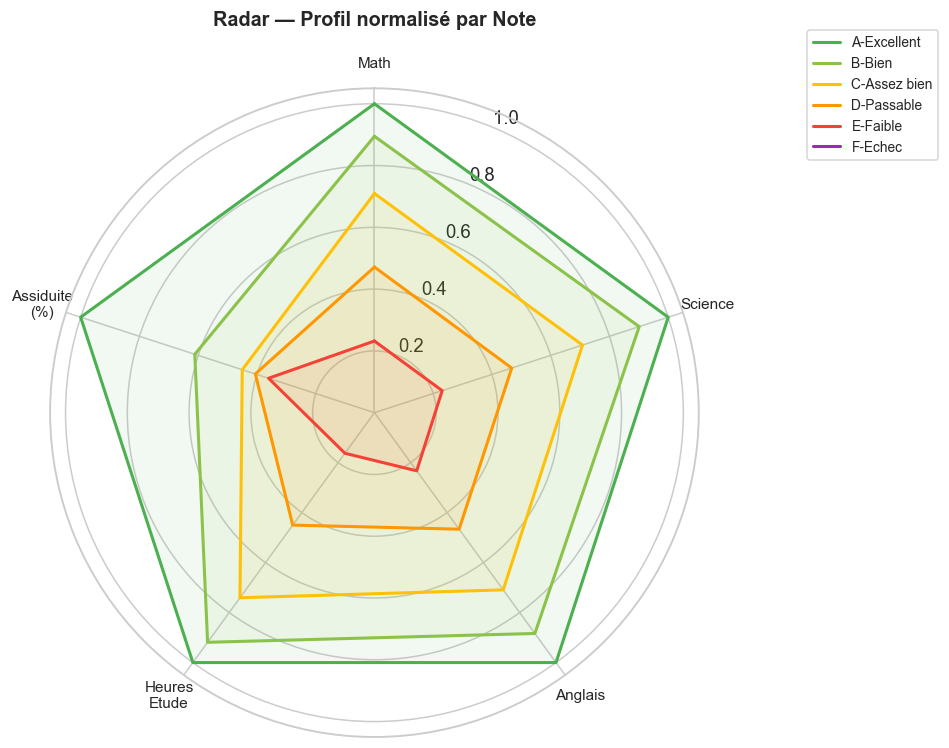

In [26]:
# Radar Chart — profil normalisé
radar_cols = SCORE_COLS + ["study_hours","attendance_percentage"]
cats = ["Math","Science","Anglais","Heures\nEtude","Assiduite\n(%)"]

rn = (profile[radar_cols] - profile[radar_cols].min()) /      (profile[radar_cols].max() - profile[radar_cols].min())

N = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, size=10)

for grade, color, label in zip(GRADE_ORDER, GRADE_COLORS, GRADE_LABELS):
    vals = rn.loc[grade, radar_cols].tolist() + [rn.loc[grade, radar_cols[0]]]
    ax.plot(angles, vals, lw=2, color=color, label=label)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_title("Radar — Profil normalisé par Note", pad=20, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

### Conclusions

**Facteurs les plus influents :** heures d'étude · taux d'assiduité · scores par matière

**Règle principale :** peu d'étude + présence moyenne → performance faible *(lift = 3.14)*

**Modèle retenu :** Random Forest (78% accuracy) — plus robuste que le Decision Tree (70%)

---
*Mini-Projet Data Mining — 2025*